- content
- status

# 1. API 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

# 2. State 정의

In [5]:
from typing import Annotated, Literal, NotRequired
from typing_extensions import TypedDict
from langchain.agents import AgentState


class Todo(TypedDict):
    """복잡한 워크플로우의 진행 상황을 추적하기 위한 구조화된 작업 항목."""
    content: str # 작업에 대한 짧고 구체적인 설명
    status: Literal["pending", "in_progress", "completed"] 
    # 현재 상태 - pending, in_progress, 또는 completed


def file_reducer(left, right):
    if left is None: # left: 왼쪽 딕셔너리 (기존 파일들) 없으면
        return right # 오른쪽
    elif right is None: # right: 오른쪽 딕셔너리 (새로운/업데이트된 파일들)
        return left # 왼쪽
    else:
        return {**left, **right}


class DeepAgentState(AgentState):
    todos: NotRequired[list[Todo]] # Todo 항목 리스트
    files: Annotated[NotRequired[dict[str, str]], file_reducer] # 딕셔너리로 저장된 가상 파일 시스템

# 3. TODO 도구 설명

In [2]:
from utils import show_prompt

WRITE_TODOS_DESCRIPTION = """복잡한 작업 흐름의 진행 상황을 추적하기 위해 구조화된 TODO 리스트를 생성하고 관리하세요.

## 언제 사용할까요?
- 여러 단계가 있거나 복잡한 작업이 필요한 경우
- 사용자가 여러 작업을 요청하거나 TODO 리스트 작성을 명시적으로 요구할 때
- 단일하고 단순한 작업에는 특별한 요구가 없으면 사용하지 마세요

## 구조
- content(내용), status(상태)를 가진 여러 개의 todo 객체를 하나의 리스트로 관리하세요
- 명확하고 실행 가능한 작업 설명을 사용하세요
- status는 반드시: pending(대기 중), in_progress(진행 중), completed(완료) 중 하나여야 합니다

## 모범 사례  
- 동시에 진행 중(in_progress)인 작업은 한 개만 유지하세요
- 작업이 완전히 끝나면 즉시 completed(완료)로 표시하세요
- 변경 시마다 항상 전체 최신 리스트를 다시 보내세요
- 불필요한 항목은 정리하여 리스트를 집중되게 관리하세요

## 진행 상황 업데이트
- 작업 상태 변경이나 내용 수정을 위해 TodoWrite를 다시 호출하세요
- 실시간으로 진행 상황을 반영하세요. 여러 완료 작업을 한 번에 처리하지 마세요
- 작업이 막힌 경우, in_progress 상태를 유지하고, 새로 막힌 점을 설명하는 작업을 추가하세요

## 입력 파라미터
- todos: content와 status 필드를 포함한 TODO 항목 리스트

## 반환값
에이전트의 상태를 새로운 todo 리스트로 업데이트합니다.
"""

show_prompt(WRITE_TODOS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  복잡한 작업 흐름의 진행 상황을 추적하기 위해 구조화된 TODO 리스트를 생성하고 관리하세요.                       │
│                                                                                                                 │
│  ## 언제 사용할까요?                                                                                            │
│  - 여러 단계가 있거나 복잡한 작업이 필요한 경우                                                                 │
│  - 사용자가 여러 작업을 요청하거나 TODO 리스트 작성을 명시적으로 요구할 때                                      │
│  - 단일하고 단순한 작업에는 특별한 요구가 없으면 사용하지 마세요                                                │
│                                                                                                                 │
│  ## 구조                                                                                                        │
│  - content(내용), status(상태)를 가진 여러 개의 todo 객체를 하나의 리스트로 관리하세요                          │
│  - 명확하고 실행 가능한 작업 설명을 사용하세요                                                                  │
│  - status는 반드시: pending(대기 중), in_progress(진행 중), completed(완료) 중 하나여야 합니다                  │
│                                                                                                                 │
│  ## 모범 사례                                                                                                   │
│  - 동시에 진행 중(in_progress)인 작업은 한 개만 유지하세요                                                      │
│  - 작업이 완전히 끝나면 즉시 completed(완료)로 표시하세요                                                       │
│  - 변경 시마다 항상 전체 최신 리스트를 다시 보내세요                                                            │
│  - 불필요한 항목은 정리하여 리스트를 집중되게 관리하세요                                                        │
│                                                                                                                 │
│  ## 진행 상황 업데이트                                                                                          │
│  - 작업 상태 변경이나 내용 수정을 위해 TodoWrite를 다시 호출하세요                                              │
│  - 실시간으로 진행 상황을 반영하세요. 여러 완료 작업을 한 번에 처리하지 마세요                                  │
│  - 작업이 막힌 경우, in_progress 상태를 유지하고, 새로 막힌 점을 설명하는 작업을 추가하세요                     │
│                                                                                                                 │
│  ## 입력 파라미터                                                                                               │
│  - todos: content와 status 필드를 포함한 TODO 항목 리스트                                                       │
│                                                                                                                 │
│  ## 반환값                                                                                                      │
│  에이전트의 상태를 새로운 todo 리스트로 업데이트합니다.                                                         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

# 4. Write and Read TODO 도구 구현

In [6]:
from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


@tool(description=WRITE_TODOS_DESCRIPTION, parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """작업 계획 및 추적을 위해 에이전트의 TODO 리스트를 생성하거나 업데이트합니다.

    Args:
        todos: content와 status를 가진 Todo 항목 리스트
        tool_call_id: 메시지 응답을 위한 도구 호출 식별자

    Returns:
        새 TODO 리스트로 에이전트 상태를 업데이트하는 Command
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )


@tool(parse_docstring=True)
def read_todos(
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> str:
    """에이전트 상태에서 현재 TODO 리스트를 읽어옵니다.

    이 도구를 통해 에이전트가 현재 TODO 리스트를 검색하고 검토하여
    남은 작업에 집중하고 복잡한 워크플로우의 진행 상황을 추적할 수 있습니다.

    Args:
        state: 현재 TODO 리스트를 포함하는 주입된 에이전트 상태
        tool_call_id: 메시지 추적을 위한 주입된 도구 호출 식별자

    Returns:
        현재 TODO 리스트의 포맷팅된 문자열 표현
    """
    todos = state.get("todos", [])
    if not todos:
        return "현재 리스트에 TODO가 없습니다."

    result = "현재 TODO 리스트:\n"
    for i, todo in enumerate(todos, 1):
        status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
        emoji = status_emoji.get(todo["status"], "❓")
        result += f"{i}. {emoji} {todo['content']} ({todo['status']})\n"

    return result.strip()

# 5. 에이전트 생성

In [7]:
TODO_USAGE_INSTRUCTIONS = """사용자의 요청에 따라 다음 지침을 따르세요:
1. 도구 설명에 따라 사용자 요청 시작 시 `write_todos` 도구를 사용하여 TODO 리스트를 생성하세요.
2. TODO를 완료한 후에는 `read_todos`를 사용하여 TODO 목록을 확인하고 계획을 상기하세요.
3. 수행한 작업과 TODO 내용을 대조하며 검토하세요.
4. 완료된 작업은 완료로 표시하고 다음 TODO로 진행하세요.
5. 모든 TODO를 완료할 때까지 이 과정을 반복하세요.

중요: 어떤 사용자 요청이든 항상 TODO 연구 계획을 수립하고 위 지침에 따라 연구를 수행해야 합니다.
중요: 관리해야 할 TODO의 수를 최소화하기 위해 연구 작업들을 가급적 *하나의 TODO*로 묶어서 처리하세요."""

show_prompt(TODO_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  사용자의 요청에 따라 다음 지침을 따르세요:                                                                     │
│  1. 도구 설명에 따라 사용자 요청 시작 시 `write_todos` 도구를 사용하여 TODO 리스트를 생성하세요.                │
│  2. TODO를 완료한 후에는 `read_todos`를 사용하여 TODO 목록을 확인하고 계획을 상기하세요.                        │
│  3. 수행한 작업과 TODO 내용을 대조하며 검토하세요.                                                              │
│  4. 완료된 작업은 완료로 표시하고 다음 TODO로 진행하세요.                                                       │
│  5. 모든 TODO를 완료할 때까지 이 과정을 반복하세요.                                                             │
│                                                                                                                 │
│  중요: 어떤 사용자 요청이든 항상 TODO 연구 계획을 수립하고 위 지침에 따라 연구를 수행해야 합니다.               │
│  중요: 관리해야 할 TODO의 수를 최소화하기 위해 연구 작업들을 가급적 *하나의 TODO*로 묶어서 처리하세요.          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

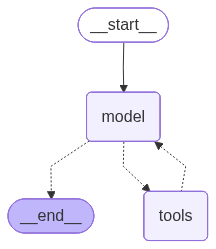

In [8]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent
from utils import format_messages

# 모의 검색 결과
search_result = """Model Context Protocol(MCP)는 Anthropic에서 개발한 오픈 스탠다드 프로토콜로, 
AI 모델과 툴, 데이터베이스, 기타 외부 시스템 간의 원활한 통합을 가능하게 합니다. 이는 표준화된 통신 레이어 역할을 하여
AI 모델이 다양한 소스로부터 데이터를 일관적이고 효율적으로 접근 및 활용할 수 있도록 합니다.
즉, MCP는 AI 어시스턴트를 외부 서비스에 연결하는 과정을 단순화하며, 데이터 교환을 위한 통합 언어를 제공합니다.
"""

# 모의 검색 도구
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """특정 주제에 대한 정보를 웹에서 검색합니다.

    이 도구는 웹 검색을 수행하고 주어진 쿼리에 대한
    관련 결과를 반환합니다. 어떤 주제에 대해 인터넷에서
    정보를 수집해야 할 때 사용하세요.

    Args:
        query: 검색 쿼리 문자열. 찾고자 하는 정보에 대해
               구체적이고 명확하게 작성하세요.

    Returns:
        검색 엔진의 검색 결과.

    Example:
        web_search("헬스케어에서의 머신러닝 응용")
    """
    return search_result

# create_agent를 사용하여 에이전트 생성
model = init_chat_model(model="openai:gpt-4.1-mini", temperature=0.0)
tools = [write_todos, web_search, read_todos]

# 모의 리서치 지침 한글화
SIMPLE_RESEARCH_INSTRUCTIONS = """중요: 반드시 web_search 도구를 한 번만 호출하고, 해당 도구에서 제공된 결과를 이용해 사용자의 질문에 답변하세요."""

# 에이전트 생성
agent = create_agent(
    model,
    tools,
    system_prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SIMPLE_RESEARCH_INSTRUCTIONS,
    state_schema=DeepAgentState,
)

# 에이전트 표시
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [9]:
# 사용 예시
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol (MCP)에 대한 짧은 요약을 해주세요.",
            }
        ],
        "todos": [],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP)에 대한 짧은 요약을 해주세요.                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol (MCP)에 대한 정보를 웹에서 검색하여 요약한다.",                        │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_qMJ4d25JCiiiTAzKWOHILnOc                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Model Context Protocol (MCP)에 대한 정보를 웹에서 검색하여 요약한다.',       │
│ 'status': 'pending'}]                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol (MCP)에 대한 정보를 웹에서 검색하여 요약한다.",                        │
│       "status": "in_progress"                                                                                   │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_S4m0XBYvSr0s6CA2n1Ar8YN3                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Model Context Protocol (MCP)에 대한 정보를 웹에서 검색하여 요약한다.',       │
│ 'status': 'in_progress'}]                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP"                                                                         │
│ }                                                                                                               │
│    ID: call_Pb4LMftSpnTavVKIfVZ3YejO                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Model Context Protocol(MCP)는 Anthropic에서 개발한 오픈 스탠다드 프로토콜로,                                    │
│ AI 모델과 툴, 데이터베이스, 기타 외부 시스템 간의 원활한 통합을 가능하게 합니다. 이는 표준화된 통신 레이어      │
│ 역할을 하여                                                                                                     │
│ AI 모델이 다양한 소스로부터 데이터를 일관적이고 효율적으로 접근 및 활용할 수 있도록 합니다.                     │
│ 즉, MCP는 AI 어시스턴트를 외부 서비스에 연결하는 과정을 단순화하며, 데이터 교환을 위한 통합 언어를 제공합니다.  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol (MCP)에 대한 정보를 웹에서 검색하여 요약한다.",                        │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_5qewdWOt6jU5LzXpqGkYSvN4                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Model Context Protocol (MCP)에 대한 정보를 웹에서 검색하여 요약한다.',       │
│ 'status': 'completed'}]                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP)는 Anthropic에서 개발한 오픈 스탠다드 프로토콜로, AI 모델과 툴, 데이터베이스, 기타  │
│ 외부 시스템 간의 원활한 통합을 가능하게 합니다. MCP는 표준화된 통신 레이어 역할을 하여 AI 모델이 다양한         │
│ 소스로부터 데이터를 일관적이고 효율적으로 접근 및 활용할 수 있도록 하며, AI 어시스턴트를 외부 서비스에 연결하는 │
│ 과정을 단순화하고 데이터 교환을 위한 통합 언어를 제공합니다.                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯